Если окружение ещё не настроено:

```python
# %pip install pandas pyarrow numpy matplotlib seaborn scikit-learn jupyter ipykernel
```


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [2]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)

# Модифицируйте в соответствии со своей задачей
TRACK = "team"  # "solo" or "team"
TRAIN_DAYS = 21           # увеличено с 14 для большего охвата истории
MAX_TRAIN_ROWS = 2_000_000
RANDOM_STATE = 42

# LightGBM гиперпараметры (early stopping подберёт нужное кол-во деревьев)
LGB_PARAMS = {
    "n_estimators": 3000,
    "learning_rate": 0.05,
    "num_leaves": 127,
    "min_child_samples": 20,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "n_jobs": -1,
    "random_state": RANDOM_STATE,
    "verbose": -1,
}

# Меняйте конфигурацию при необходимости
TRACK_CONFIG = {
    "solo": {
        "train_path": "train_solo_track.parquet",
        "test_path": "test_solo_track.parquet",
        "target_col": "target_1h",
        "forecast_points": 8,
    },
    "team": {
        "train_path": "train_team_track.parquet",
        "test_path": "test_team_track.parquet",
        "target_col": "target_2h",
        "forecast_points": 10,
    },
}

CONFIG = TRACK_CONFIG[TRACK]
TARGET_COL = CONFIG["target_col"]
FORECAST_POINTS = CONFIG["forecast_points"]
FUTURE_TARGET_COLS = [f"target_step_{step}" for step in range(1, FORECAST_POINTS + 1)]


## Загрузка данных


In [3]:
train_df = pd.read_parquet(CONFIG["train_path"])
test_df = pd.read_parquet(CONFIG["test_path"])

train_df["timestamp"] = pd.to_datetime(train_df["timestamp"])
test_df["timestamp"] = pd.to_datetime(test_df["timestamp"])

train_df = train_df.sort_values(["route_id", "timestamp"]).reset_index(drop=True)
test_df = test_df.sort_values(["route_id", "timestamp"]).reset_index(drop=True)

print("track:", TRACK)
print("train shape:", train_df.shape)
print("test shape:", test_df.shape)


track: team
train shape: (4342000, 12)
test shape: (10000, 3)


In [4]:
display(train_df)
display(test_df)


,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h
0,26,0,2025-03-01 00:00:00,0,46,0,0,12,9,0,0,79.0
1,26,0,2025-03-01 00:30:00,0,34,0,0,16,0,187,0,88.0
2,26,0,2025-03-01 01:00:00,0,19,0,0,31,0,0,0,88.0
3,26,0,2025-03-01 01:30:00,0,33,0,0,36,129,0,0,88.0
4,26,0,2025-03-01 02:00:00,0,24,0,0,55,12,0,0,103.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4341995,13,999,2025-05-30 08:30:00,531,171,416,501,767,498,2153,30,27.0
4341996,13,999,2025-05-30 09:00:00,632,170,629,540,944,809,1411,14,19.0
4341997,13,999,2025-05-30 09:30:00,822,222,616,552,823,547,2510,0,15.0
4341998,13,999,2025-05-30 10:00:00,973,241,875,872,976,1174,0,0,13.0


,id,route_id,timestamp
0,4900,0,2025-05-30 11:00:00
1,4901,0,2025-05-30 11:30:00
2,4902,0,2025-05-30 12:00:00
3,4903,0,2025-05-30 12:30:00
4,4904,0,2025-05-30 13:00:00
...,...,...,...
9995,3795,999,2025-05-30 13:30:00
9996,3796,999,2025-05-30 14:00:00
9997,3797,999,2025-05-30 14:30:00
9998,3798,999,2025-05-30 15:00:00


In [5]:
print("Train date range:", train_df["timestamp"].min(), "->", train_df["timestamp"].max())
print("Test date range:", test_df["timestamp"].min(), "->", test_df["timestamp"].max())
print("Train routes:", train_df["route_id"].nunique())
print("Test routes:", test_df["route_id"].nunique())


Train date range: 2025-03-01 00:00:00 -> 2025-05-30 10:30:00
Test date range: 2025-05-30 11:00:00 -> 2025-05-30 15:30:00
Train routes: 1000
Test routes: 1000


## EDA train-данных


In [6]:
overview = pd.DataFrame(
    {
        "dtype": train_df.dtypes.astype(str),
        "missing_cnt": train_df.isna().sum(),
        "missing_pct": (train_df.isna().mean() * 100).round(4),
        "n_unique": train_df.nunique(dropna=False),
    }
)
overview


,dtype,missing_cnt,missing_pct,n_unique
office_from_id,int64,0,0.0,53
route_id,int64,0,0.0,1000
timestamp,datetime64[ns],0,0.0,4342
status_1,int64,0,0.0,19752
status_2,int64,0,0.0,2127
status_3,int64,0,0.0,17998
status_4,int64,0,0.0,14416
status_5,int64,0,0.0,17108
status_6,int64,0,0.0,17616
status_7,int64,0,0.0,38219


In [7]:
train_df

,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h
0,26,0,2025-03-01 00:00:00,0,46,0,0,12,9,0,0,79.0
1,26,0,2025-03-01 00:30:00,0,34,0,0,16,0,187,0,88.0
2,26,0,2025-03-01 01:00:00,0,19,0,0,31,0,0,0,88.0
3,26,0,2025-03-01 01:30:00,0,33,0,0,36,129,0,0,88.0
4,26,0,2025-03-01 02:00:00,0,24,0,0,55,12,0,0,103.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4341995,13,999,2025-05-30 08:30:00,531,171,416,501,767,498,2153,30,27.0
4341996,13,999,2025-05-30 09:00:00,632,170,629,540,944,809,1411,14,19.0
4341997,13,999,2025-05-30 09:30:00,822,222,616,552,823,547,2510,0,15.0
4341998,13,999,2025-05-30 10:00:00,973,241,875,872,976,1174,0,0,13.0


In [8]:
print(train_df[train_df['office_from_id'] == 26].route_id.unique())
print(train_df[train_df['office_from_id'] == 13].route_id.unique())

[  0  77  96 122 455 461 463 591 644 687]
[  8  11  20  59  66  85  94 101 104 114 115 116 120 177 211 219 254 258
 264 274 276 281 311 333 345 374 427 434 441 457 462 472 478 490 504 509
 534 537 605 618 624 632 640 657 662 664 694 695 726 737 753 755 758 763
 822 825 922 942 948 952 972 983 986 999]


In [9]:
status_cols = sorted([col for col in train_df.columns if col.startswith("status_")])
print("Status columns:", status_cols)
print("Target column:", TARGET_COL)
print("Forecast points:", FORECAST_POINTS)


Status columns: ['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'status_7', 'status_8']
Target column: target_2h
Forecast points: 10


In [25]:
df_conform = pd.read_csv('data/non_conformity_scores_norm.csv')
df_conform

,route_id,horizon,score
0,426,0-2h,0.199432
1,10,0-2h,0.009183
2,347,0-2h,0.586150
3,835,0-2h,0.019426
4,236,0-2h,0.100346
...,...,...,...
602995,659,4-6h,0.612431
602996,658,4-6h,0.140575
602997,657,4-6h,0.197641
602998,670,4-6h,0.173468


In [26]:
df_conform[(df_conform['route_id'] == 809) & (df_conform['horizon'] == '0-2h')].sort_values('score')

,route_id,horizon,score
41418,809,0-2h,0.004745
118448,809,0-2h,0.014976
179014,809,0-2h,0.020262
5392,809,0-2h,0.027352
32062,809,0-2h,0.043643
...,...,...,...
156362,809,0-2h,5.105431
126993,809,0-2h,8.722104
125543,809,0-2h,10.664012
127187,809,0-2h,11.760907


## Feature Engineering

In [8]:
def make_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Добавляет временны́е, лаговые, скользящие и агрегационные фичи.
    Предполагает, что TARGET_COL и status_* уже присутствуют в df.
    Сортирует по (route_id, timestamp) и возвращает новый DataFrame.
    """
    df = df.sort_values(["route_id", "timestamp"]).copy()

    # ── Временны́е фичи ────────────────────────────────────────────────────────
    df["hour"]        = df["timestamp"].dt.hour
    df["day_of_week"] = df["timestamp"].dt.dayofweek
    df["is_weekend"]  = (df["day_of_week"] >= 5).astype(np.int8)
    df["hour_sin"]    = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"]    = np.cos(2 * np.pi * df["hour"] / 24)
    df["dow_sin"]     = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["dow_cos"]     = np.cos(2 * np.pi * df["day_of_week"] / 7)

    g = df.groupby("route_id", sort=False)

    # ── Лаги целевой переменной ────────────────────────────────────────────────
    for lag in [1, 2, 4, 8, 16, 48]:
        df[f"target_lag_{lag}"] = g[TARGET_COL].shift(lag)

    # ── Скользящие статистики целевой переменной ───────────────────────────────
    for w in [4, 8, 16, 48]:
        df[f"target_roll_mean_{w}"] = g[TARGET_COL].transform(
            lambda x, w=w: x.shift(1).rolling(w, min_periods=1).mean()
        )
        df[f"target_roll_std_{w}"] = g[TARGET_COL].transform(
            lambda x, w=w: x.shift(1).rolling(w, min_periods=2).std().fillna(0)
        )

    # ── EMA целевой переменной ─────────────────────────────────────────────────
    df["target_ema_8"]  = g[TARGET_COL].transform(
        lambda x: x.shift(1).ewm(span=8,  adjust=False).mean()
    )
    df["target_ema_24"] = g[TARGET_COL].transform(
        lambda x: x.shift(1).ewm(span=24, adjust=False).mean()
    )

    # ── Фичи по статусам ──────────────────────────────────────────────────────
    _scols = sorted([c for c in df.columns if c.startswith("status_") and
                     not c.endswith("_ratio") and "_lag" not in c])
    df["status_sum"] = df[_scols].sum(axis=1)
    for col in _scols:
        df[f"{col}_ratio"] = df[col] / (df["status_sum"] + 1e-6)
        df[f"{col}_lag1"]  = g[col].shift(1)
        df[f"{col}_lag2"]  = g[col].shift(2)

    # ── Агрегации на уровне склада (office_from_id × timestamp) ───────────────
    office_agg = (
        df.groupby(["office_from_id", "timestamp"])[TARGET_COL]
        .agg(office_target_mean="mean", office_target_sum="sum", office_target_std="std")
        .reset_index()
    )
    df = df.merge(office_agg, on=["office_from_id", "timestamp"], how="left")
    df["office_target_std"] = df["office_target_std"].fillna(0)

    return df.sort_values(["route_id", "timestamp"]).reset_index(drop=True)


In [9]:
print("Applying feature engineering to train_df...")
train_df = make_features(train_df)
print("train_df shape after features:", train_df.shape)
new_feat_cols = [c for c in train_df.columns
                 if c not in {"route_id", "office_from_id", "timestamp", TARGET_COL}
                 and not c.startswith("status_")]
print(f"New engineered columns ({len(new_feat_cols)}):", new_feat_cols)


Applying feature engineering to train_df...
train_df shape after features: (4342000, 63)
New engineered columns (26): ['hour', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'target_lag_1', 'target_lag_2', 'target_lag_4', 'target_lag_8', 'target_lag_16', 'target_lag_48', 'target_roll_mean_4', 'target_roll_std_4', 'target_roll_mean_8', 'target_roll_std_8', 'target_roll_mean_16', 'target_roll_std_16', 'target_roll_mean_48', 'target_roll_std_48', 'target_ema_8', 'target_ema_24', 'office_target_mean', 'office_target_sum', 'office_target_std']


## Распределения


KeyboardInterrupt: 

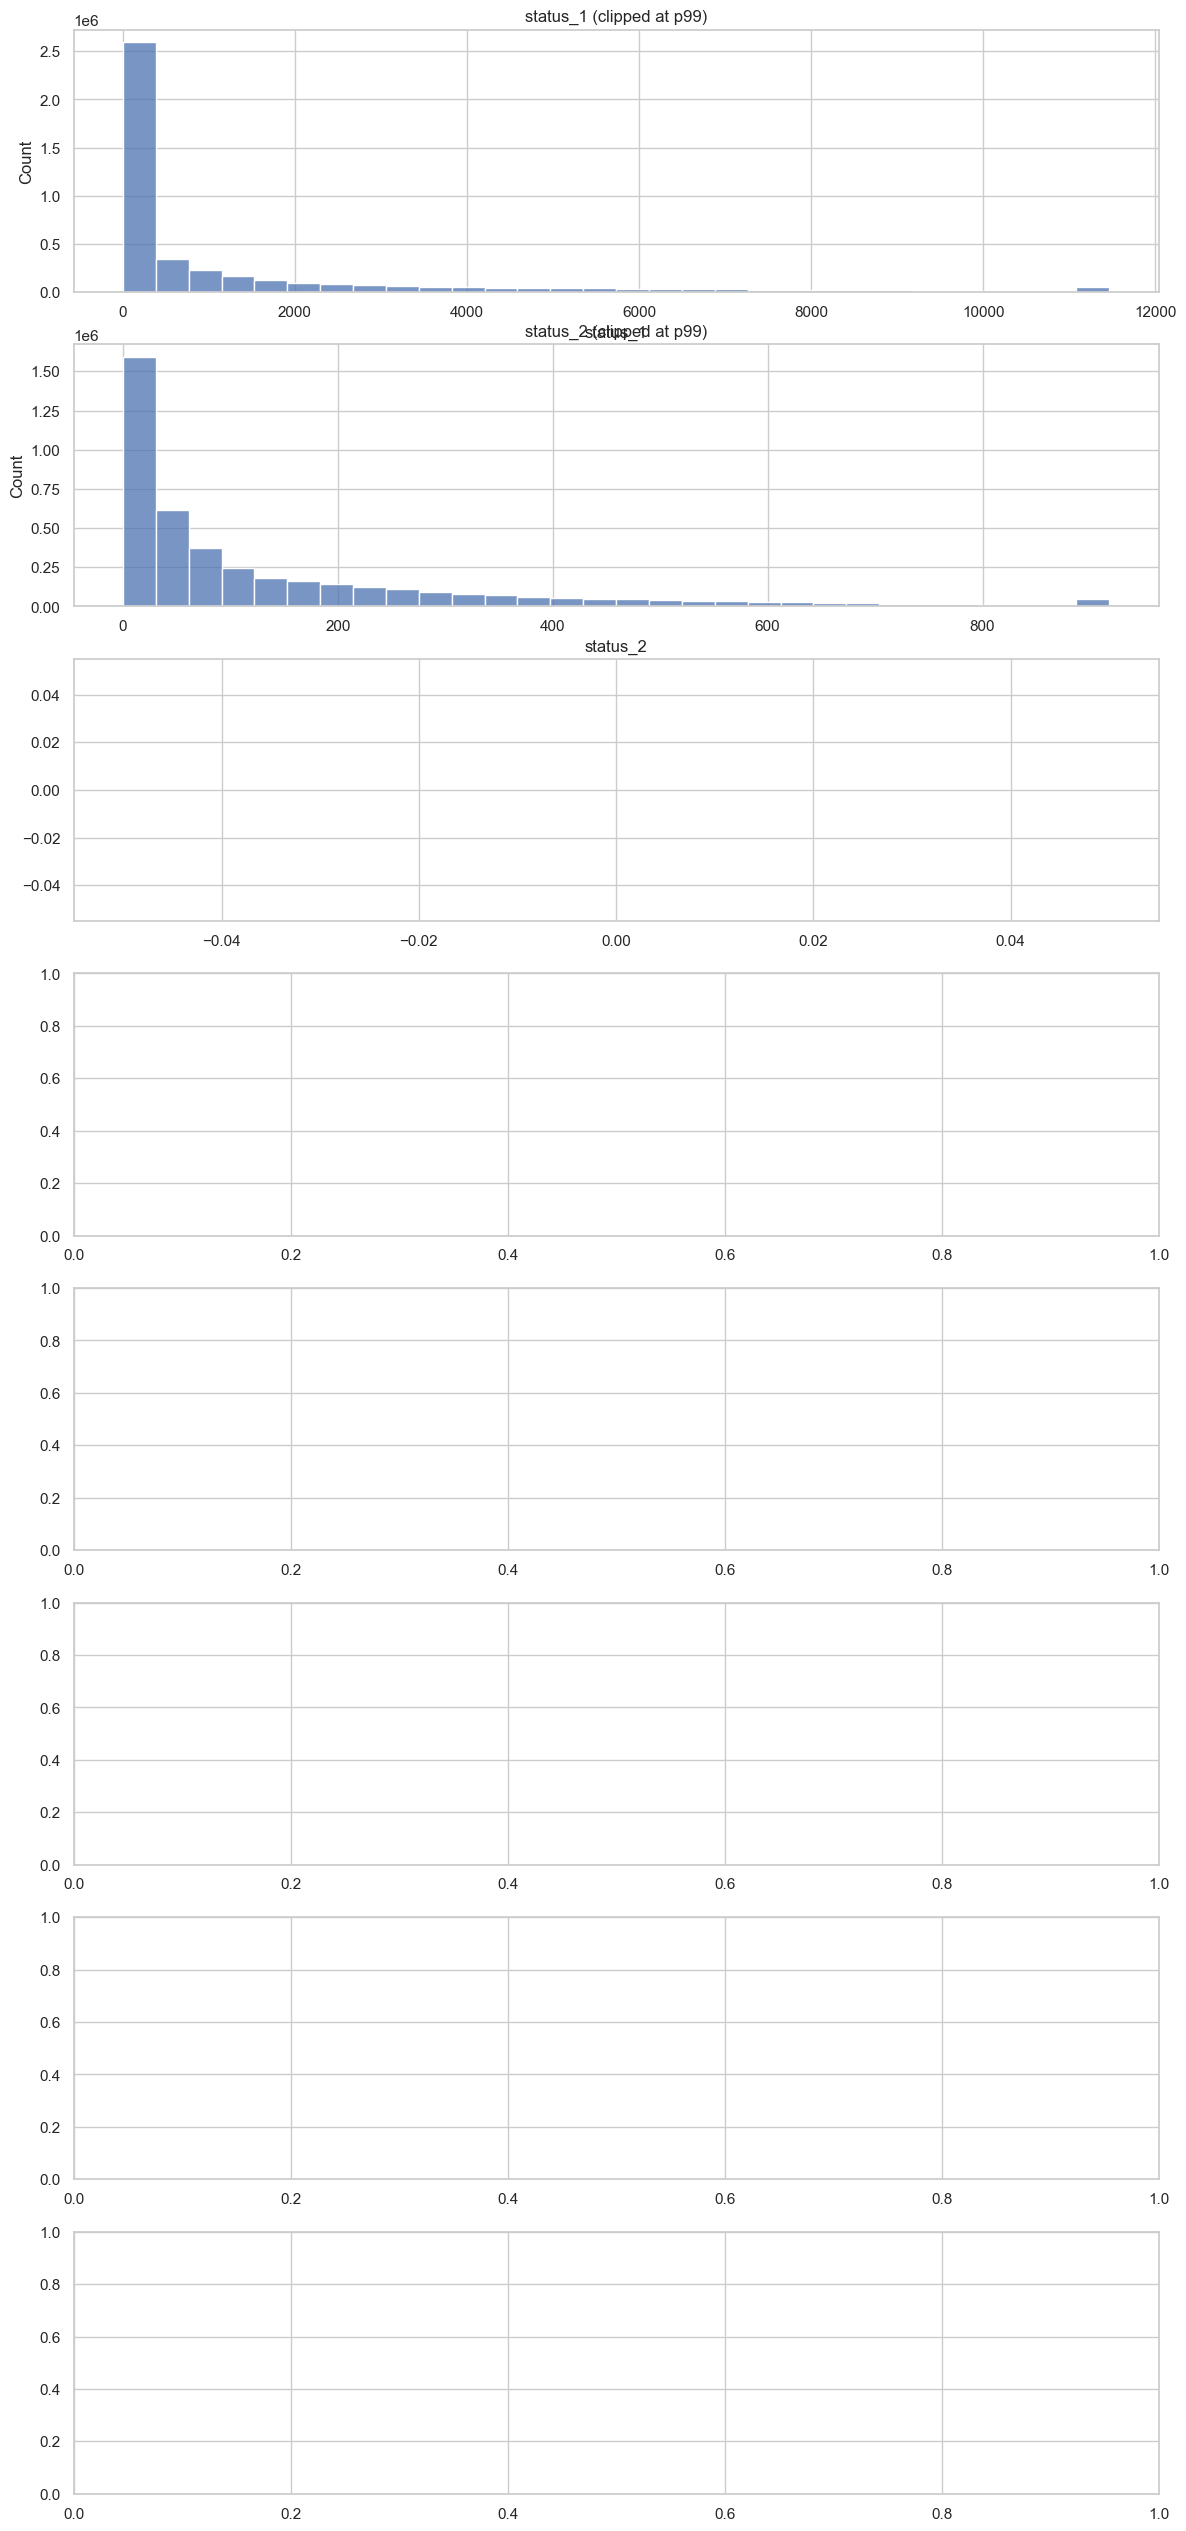

In [10]:
fig, axes = plt.subplots(len(status_cols), 1, figsize=(14, 4 * len(status_cols)))

if len(status_cols) == 1:
    axes = [axes]

for i, col in enumerate(status_cols):
    sns.histplot(train_df[col].clip(upper=train_df[col].quantile(0.99)), bins=30, ax=axes[i], kde=False)
    axes[i].set_title(f"{col} (clipped at p99)")

plt.tight_layout()
plt.show()


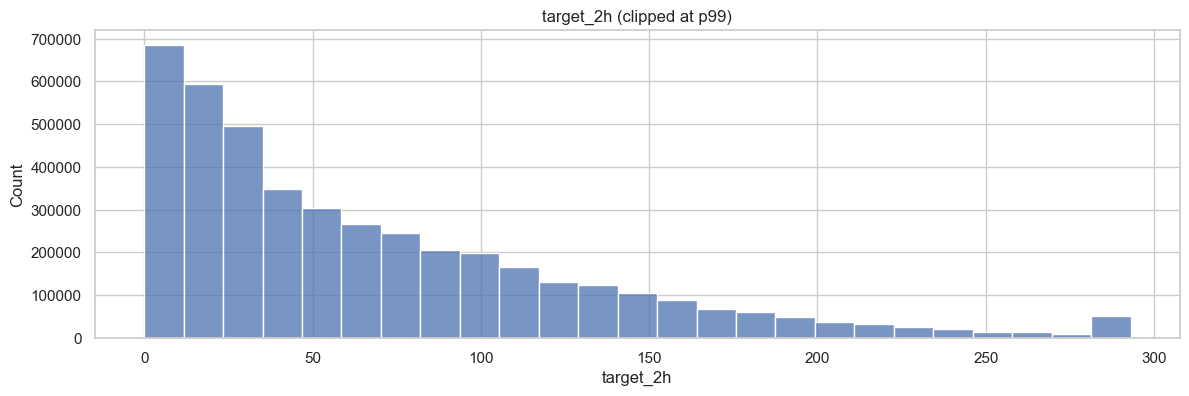

In [13]:
plt.figure(figsize=(14, 4))
sns.histplot(train_df[TARGET_COL].clip(upper=train_df[TARGET_COL].quantile(0.99)), bins=25, kde=False)
plt.title(f"{TARGET_COL} (clipped at p99)")
plt.show()


## Генерируем будущие таргеты


In [11]:
route_group = train_df.groupby("route_id", sort=False)

for step in range(1, FORECAST_POINTS + 1):
    train_df[f"target_step_{step}"] = route_group[TARGET_COL].shift(-step)

train_df[["route_id", "timestamp", TARGET_COL] + FUTURE_TARGET_COLS]


,route_id,timestamp,target_2h,target_step_1,target_step_2,target_step_3,target_step_4,target_step_5,target_step_6,target_step_7,target_step_8,target_step_9,target_step_10
0,0,2025-03-01 00:00:00,79.0,88.0,88.0,88.0,103.0,94.0,106.0,127.0,33.0,33.0,27.0
1,0,2025-03-01 00:30:00,88.0,88.0,88.0,103.0,94.0,106.0,127.0,33.0,33.0,27.0,6.0
2,0,2025-03-01 01:00:00,88.0,88.0,103.0,94.0,106.0,127.0,33.0,33.0,27.0,6.0,6.0
3,0,2025-03-01 01:30:00,88.0,103.0,94.0,106.0,127.0,33.0,33.0,27.0,6.0,6.0,6.0
4,0,2025-03-01 02:00:00,103.0,94.0,106.0,127.0,33.0,33.0,27.0,6.0,6.0,6.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4341995,999,2025-05-30 08:30:00,27.0,19.0,15.0,13.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN
4341996,999,2025-05-30 09:00:00,19.0,15.0,13.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4341997,999,2025-05-30 09:30:00,15.0,13.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4341998,999,2025-05-30 10:00:00,13.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
supervised_df = train_df.dropna(subset=FUTURE_TARGET_COLS).copy()
print("Rows with future targets:", supervised_df.shape)


Rows with future targets: (4332000, 73)


## Корреляции


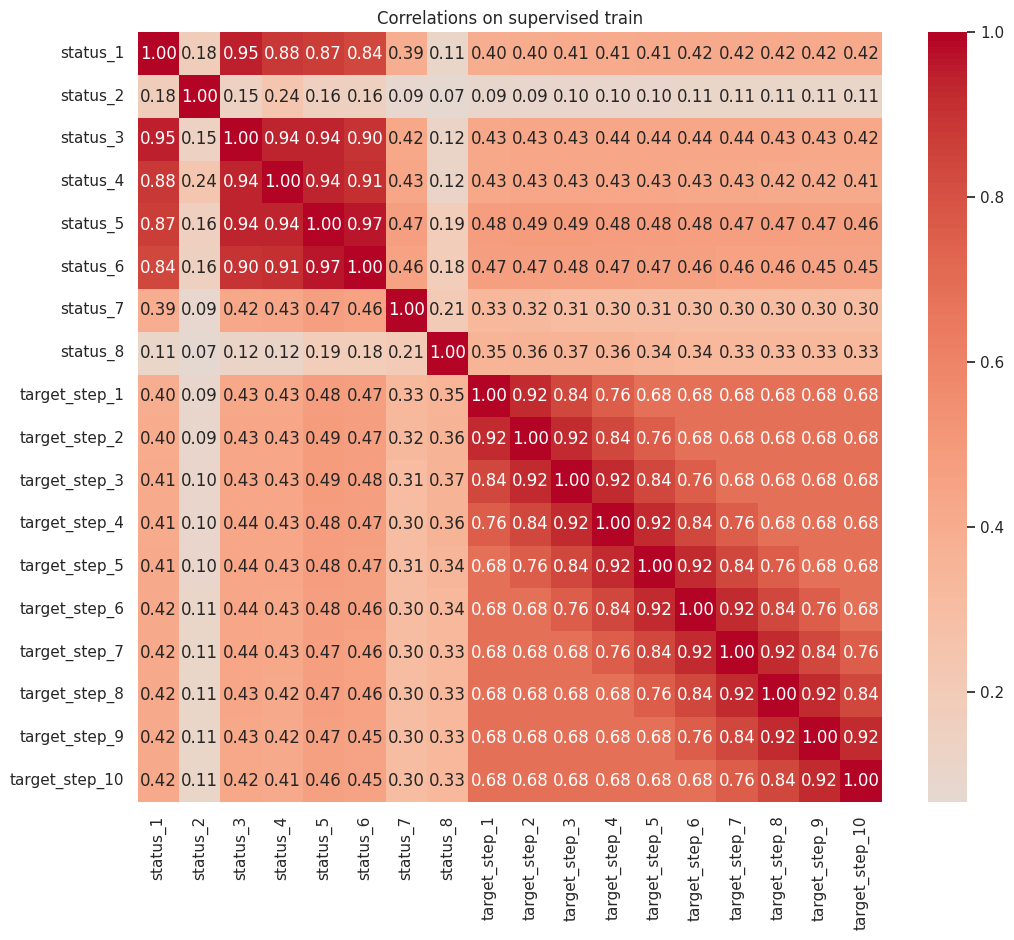

In [72]:
corr_cols = status_cols + FUTURE_TARGET_COLS
corr = supervised_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlations on supervised train")
plt.show()


## Подготовка train и test


In [13]:
feature_cols = [col for col in train_df.columns if col not in {TARGET_COL, "timestamp", "id", *FUTURE_TARGET_COLS}]

print("Feature columns:", feature_cols)


Feature columns: ['office_from_id', 'route_id', 'status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'status_7', 'status_8', 'hour', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'target_lag_1', 'target_lag_2', 'target_lag_4', 'target_lag_8', 'target_lag_16', 'target_lag_48', 'target_roll_mean_4', 'target_roll_std_4', 'target_roll_mean_8', 'target_roll_std_8', 'target_roll_mean_16', 'target_roll_std_16', 'target_roll_mean_48', 'target_roll_std_48', 'target_ema_8', 'target_ema_24', 'status_sum', 'status_1_ratio', 'status_1_lag1', 'status_1_lag2', 'status_2_ratio', 'status_2_lag1', 'status_2_lag2', 'status_3_ratio', 'status_3_lag1', 'status_3_lag2', 'status_4_ratio', 'status_4_lag1', 'status_4_lag2', 'status_5_ratio', 'status_5_lag1', 'status_5_lag2', 'status_6_ratio', 'status_6_lag1', 'status_6_lag2', 'status_7_ratio', 'status_7_lag1', 'status_7_lag2', 'status_8_ratio', 'status_8_lag1', 'status_8_lag2', 'office_target_mean', 'office_target

In [14]:
train_model_df = supervised_df[feature_cols + ["timestamp"] + FUTURE_TARGET_COLS].copy()
train_model_df = train_model_df.rename(columns={"timestamp": "source_timestamp"})

train_ts_max = train_model_df["source_timestamp"].max()
train_window_start = train_ts_max - pd.Timedelta(days=TRAIN_DAYS)
train_model_df = train_model_df[train_model_df["source_timestamp"] >= train_window_start].copy()

print("Recent train rows:", train_model_df.shape)


Recent train rows: (1009000, 72)


In [15]:
# последний момент факта, из которого делаем прогноз
inference_ts = train_df["timestamp"].max()
test_model_df = train_df[train_df["timestamp"] == inference_ts]

print("Test rows:", test_model_df.shape)


Test rows: (1000, 73)


## Time-based split


In [16]:
train_model_df = train_model_df.sort_values("source_timestamp").copy()
split_point = train_model_df["source_timestamp"].quantile(0.8)

fit_df = train_model_df[train_model_df["source_timestamp"] <= split_point].copy()
valid_df = train_model_df[train_model_df["source_timestamp"] > split_point].copy()

if len(fit_df) > MAX_TRAIN_ROWS:
    fit_df = fit_df.sample(MAX_TRAIN_ROWS, random_state=RANDOM_STATE)

print("Fit rows:", fit_df.shape)
print("Valid rows:", valid_df.shape)


Fit rows: (808000, 72)
Valid rows: (201000, 72)


In [17]:
X_fit = fit_df[feature_cols].copy()
y_fit = fit_df[FUTURE_TARGET_COLS].copy()

X_valid = valid_df[feature_cols].copy()
y_valid = valid_df[FUTURE_TARGET_COLS].copy()

X_test = test_model_df[feature_cols].copy()


## LightGBM: отдельная модель на каждый горизонт прогноза


In [18]:
categorical_features = [col for col in feature_cols if col.endswith("_id")]
numeric_features = [col for col in feature_cols if col not in categorical_features]

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)


Categorical features: ['office_from_id', 'route_id']
Numeric features: ['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'status_7', 'status_8', 'hour', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'target_lag_1', 'target_lag_2', 'target_lag_4', 'target_lag_8', 'target_lag_16', 'target_lag_48', 'target_roll_mean_4', 'target_roll_std_4', 'target_roll_mean_8', 'target_roll_std_8', 'target_roll_mean_16', 'target_roll_std_16', 'target_roll_mean_48', 'target_roll_std_48', 'target_ema_8', 'target_ema_24', 'status_sum', 'status_1_ratio', 'status_1_lag1', 'status_1_lag2', 'status_2_ratio', 'status_2_lag1', 'status_2_lag2', 'status_3_ratio', 'status_3_lag1', 'status_3_lag2', 'status_4_ratio', 'status_4_lag1', 'status_4_lag2', 'status_5_ratio', 'status_5_lag1', 'status_5_lag2', 'status_6_ratio', 'status_6_lag1', 'status_6_lag2', 'status_7_ratio', 'status_7_lag1', 'status_7_lag2', 'status_8_ratio', 'status_8_lag1', 'status_8_lag2', 'office_targ

In [19]:
# LightGBM обрабатывает NaN и числа нативно;
# для категориальных колонок ставим dtype=category — LGB распознаёт автоматически.
for col in categorical_features:
    all_cats = pd.concat([X_fit[col], X_valid[col], X_test[col]]).astype(str).unique()
    cat_dtype = pd.CategoricalDtype(categories=all_cats)
    X_fit[col]   = X_fit[col].astype(str).astype(cat_dtype)
    X_valid[col] = X_valid[col].astype(str).astype(cat_dtype)
    X_test[col]  = X_test[col].astype(str).astype(cat_dtype)

print("Feature matrix shapes:")
print("  X_fit   :", X_fit.shape)
print("  X_valid :", X_valid.shape)
print("  X_test  :", X_test.shape)
print("Categorical features:", categorical_features)
print("Numeric features count:", len(numeric_features))


Feature matrix shapes:
  X_fit   : (808000, 61)
  X_valid : (201000, 61)
  X_test  : (1000, 61)
Categorical features: ['office_from_id', 'route_id']
Numeric features count: 59


In [20]:
models = {}
print(f"Training {len(FUTURE_TARGET_COLS)} LGBMRegressor models (one per forecast step)...")

for step_col in FUTURE_TARGET_COLS:
    m = lgb.LGBMRegressor(**LGB_PARAMS)
    m.fit(
        X_fit, y_fit[step_col],
        eval_set=[(X_valid, y_valid[step_col])],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=500),
        ],
    )
    models[step_col] = m
    print(f"  {step_col:20s}  best_iteration={m.best_iteration_:4d}")

print("\nAll models trained.")


Training 10 LGBMRegressor models (one per forecast step)...
  target_step_1         best_iteration= 345
  target_step_2         best_iteration= 139
  target_step_3         best_iteration= 113
  target_step_4         best_iteration= 114
  target_step_5         best_iteration= 104
  target_step_6         best_iteration= 101
  target_step_7         best_iteration= 110
  target_step_8         best_iteration= 109
  target_step_9         best_iteration= 119
  target_step_10        best_iteration= 150

All models trained.


In [21]:
def predict_steps(X: pd.DataFrame) -> pd.DataFrame:
    """Предсказывает все горизонты, обнуляет отрицательные значения."""
    preds = {col: np.clip(models[col].predict(X), 0, None) for col in FUTURE_TARGET_COLS}
    return pd.DataFrame(preds, index=X.index)


fit_pred_df   = predict_steps(X_fit)
valid_pred_df = predict_steps(X_valid)
test_pred_df  = predict_steps(X_test)

# ── Вычисляем коэффициент коррекции смещения на валидации ─────────────────────
y_valid_flat    = y_valid.to_numpy().flatten()
valid_pred_flat = valid_pred_df.to_numpy().flatten()
bias_factor     = y_valid_flat.sum() / (valid_pred_flat.sum() + 1e-8)
print(f"Bias correction factor (val): {bias_factor:.4f}")
print(f"  → sum(y_true)={y_valid_flat.sum():.0f}  sum(y_pred)={valid_pred_flat.sum():.0f}")

valid_pred_df.head()


Bias correction factor (val): 1.0046
  → sum(y_true)=149343262  sum(y_pred)=148653628


,target_step_1,target_step_2,target_step_3,target_step_4,target_step_5,target_step_6,target_step_7,target_step_8,target_step_9,target_step_10
1853823,30.658002,45.897287,56.432370,71.826876,70.827327,69.111950,70.542100,72.004073,72.928476,73.486932
47551,165.268891,163.946160,166.422364,163.154870,152.754793,151.392298,147.917513,146.103151,145.529077,145.368486
1510805,14.237942,15.742267,17.101197,18.368340,18.865815,19.042627,18.902819,18.864261,18.525636,18.752150
3629701,71.973065,73.611628,77.851035,72.892419,72.951762,71.649159,72.570030,71.018684,70.388023,69.568327
1028843,14.907267,16.720030,18.547385,18.658565,18.844110,18.981355,19.278761,19.665220,18.711577,17.645422


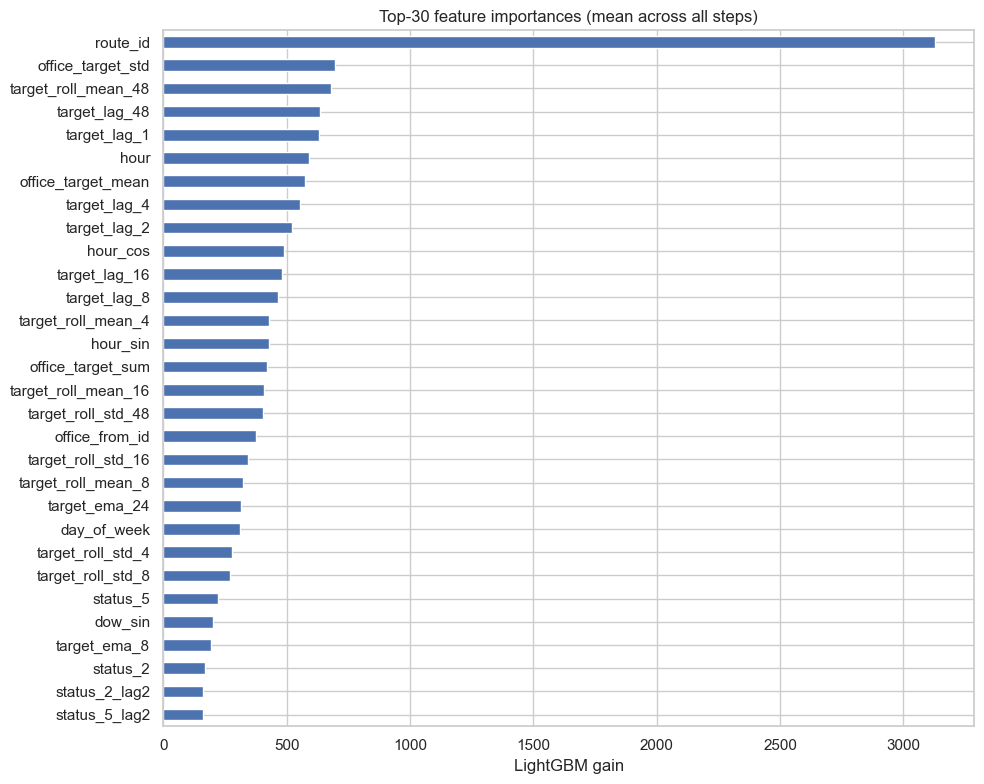

In [22]:
# ── Feature importance (среднее по всем горизонтам) ───────────────────────────
importances = pd.DataFrame(
    {col: models[col].feature_importances_ for col in FUTURE_TARGET_COLS},
    index=X_fit.columns,
)
mean_imp = importances.mean(axis=1).sort_values(ascending=False).head(30)

plt.figure(figsize=(10, 8))
mean_imp.sort_values().plot(kind="barh")
plt.title("Top-30 feature importances (mean across all steps)")
plt.xlabel("LightGBM gain")
plt.tight_layout()
plt.show()


## Метрики


In [23]:
class WapePlusRbias:
    """Calculates as WAPE + Relative Bias."""

    @property
    def name(self) -> str:
        """Возвращает имя метрики."""
        return "wape_plus_rbias"

    def calculate(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        """Рассчитывает значение метрики."""
        wape = (np.abs(y_pred - y_true)).sum() / y_true.sum()
        rbias = np.abs(y_pred.sum() / y_true.sum() - 1)
        return wape + rbias


metric = WapePlusRbias()

In [24]:
print('Метрики на тесте (по горизонтам):')
display(np.round(metric.calculate(y_fit, fit_pred_df), 2))

print('Общая метрика на тесте:')
print(f'{metric.calculate(y_fit.to_numpy().flatten(), fit_pred_df.to_numpy().flatten()):.2f}')

Метрики на тесте (по горизонтам):


target_step_1     0.19
target_step_2     0.23
target_step_3     0.26
target_step_4     0.27
target_step_5     0.27
target_step_6     0.27
target_step_7     0.27
target_step_8     0.27
target_step_9     0.27
target_step_10    0.27
dtype: float64

Общая метрика на тесте:
0.26


In [ ]:
# print('Метрики на тесте (по горизонтам):')
# display(np.round(metric.calculate(y_fit, fit_pred_df), 2))

# print('Общая метрика на тесте:')
# print(f'{metric.calculate(y_fit.to_numpy().flatten(), fit_pred_df.to_numpy().flatten()):.2f}')

Метрики на тесте (по горизонтам):


target_step_1     0.29
target_step_2     0.29
target_step_3     0.29
target_step_4     0.29
target_step_5     0.29
target_step_6     0.30
target_step_7     0.30
target_step_8     0.30
target_step_9     0.30
target_step_10    0.30
dtype: float64

Общая метрика на тесте:
0.29


In [25]:
print('Метрики на валидации (по горизонтам):')
display(np.round(metric.calculate(y_valid, valid_pred_df), 2))

print('Общая метрика на валидации:')
print(f'{metric.calculate(y_valid.to_numpy().flatten(), valid_pred_df.to_numpy().flatten()):.2f}')

Метрики на валидации (по горизонтам):


target_step_1     0.20
target_step_2     0.24
target_step_3     0.27
target_step_4     0.28
target_step_5     0.28
target_step_6     0.29
target_step_7     0.28
target_step_8     0.28
target_step_9     0.28
target_step_10    0.28
dtype: float64

Общая метрика на валидации:
0.27


In [ ]:
# print('Метрики на валидации (по горизонтам):')
# display(np.round(metric.calculate(y_valid, valid_pred_df), 2))

# print('Общая метрика на валидации:')
# print(f'{metric.calculate(y_valid.to_numpy().flatten(), valid_pred_df.to_numpy().flatten()):.2f}')

Метрики на валидации (по горизонтам):


target_step_1     0.31
target_step_2     0.31
target_step_3     0.31
target_step_4     0.31
target_step_5     0.32
target_step_6     0.32
target_step_7     0.33
target_step_8     0.33
target_step_9     0.34
target_step_10    0.34
dtype: float64

Общая метрика на валидации:
0.32


## Конвертируем прогноз в нужный формат 


In [ ]:
# ── Применяем bias correction и clip к тестовым предсказаниям ─────────────────
test_pred_corrected = (test_pred_df * bias_factor).clip(lower=0)

# добавляем к прогнозу маршруты
test_pred_corrected = test_pred_corrected.copy()
test_pred_corrected["route_id"] = X_test["route_id"].values

# разворачиваем target_step_* в строки
forecast_df = test_pred_corrected.melt(
    id_vars="route_id",
    value_vars=[c for c in test_pred_corrected.columns if c.startswith("target_step_")],
    var_name="step",
    value_name="forecast"
)

# достаем номер шага из target_step_1, target_step_2, ...
forecast_df["step_num"] = forecast_df["step"].str.extract(r"(\d+)").astype(int)

# строим timestamp: каждый шаг = +30 минут от времени прогноза
forecast_df["timestamp"] = inference_ts + pd.to_timedelta(forecast_df["step_num"] * 30, unit="m")

# оставляем нужные столбцы
forecast_df = forecast_df[["route_id", "timestamp", "forecast"]].sort_values(
    ["route_id", "timestamp"]
).reset_index(drop=True)

forecast_df = test_df.merge(forecast_df, "outer")[["id", "forecast"]]
forecast_df = forecast_df.rename(columns={"forecast": "y_pred"})


In [29]:
forecast_df.head()

,id,y_pred
0,4900,20.732129
1,4901,20.704784
2,4902,20.595085
3,4903,20.679748
4,4904,20.674765


In [30]:
# проверяем, что все точки получены
assert forecast_df['id'].isna().sum() == 0


## Выгрузка CSV


In [88]:
submission_path =  f"submission_{TRACK}.csv"
joined_path =  f"test_with_forecast_{TRACK}.csv"

forecast_df.to_csv(submission_path, index=False)

print("submission saved to:", submission_path)

submission saved to: submission_team.csv
